# YOLO12 Model Training for Animal Detection

This notebook includes:
1. Data augmentation
2. Model training
3. Model evaluation
4. Model export


In [2]:
# Import necessary libraries
import os
import shutil
from pathlib import Path
import yaml
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import torch

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Set paths - handle both notebook execution and script execution
# If running from notebook in yolo_training folder, go up one level
# If running from project root, use current directory
current_dir = Path.cwd()
if current_dir.name == 'yolo_training':
    BASE_DIR = current_dir.parent
else:
    BASE_DIR = current_dir

DATA_DIR = BASE_DIR / "animales"
DATA_YAML = DATA_DIR / "data.yaml"

print(f"Current working directory: {current_dir}")
print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Data YAML exists: {DATA_YAML.exists()}")


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\CHARBEL\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cpu
Current working directory: c:\Users\CHARBEL\Desktop\Lingo\yolo_training
Base directory: c:\Users\CHARBEL\Desktop\Lingo
Data directory: c:\Users\CHARBEL\Desktop\Lingo\animales
Data YAML exists: True


## 1. Data Augmentation Setup


In [3]:
# Load dataset configuration
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset Configuration:")
print(f"Number of classes: {data_config['nc']}")
print(f"Class names: {data_config['names']}")
print(f"Train path: {data_config['train']}")
print(f"Val path: {data_config['val']}")
print(f"Test path: {data_config['test']}")

# Count images in each split
train_images = len(list((DATA_DIR / data_config['train']).glob('*.jpg')))
val_images = len(list((DATA_DIR / data_config['val']).glob('*.jpg')))
test_images = len(list((DATA_DIR / data_config['test']).glob('*.jpg')))

print(f"\nDataset Statistics:")
print(f"Training images: {train_images}")
print(f"Validation images: {val_images}")
print(f"Test images: {test_images}")


Dataset Configuration:
Number of classes: 9
Class names: ['Cat', 'Dog', 'Pig', 'bird', 'cow', 'duck', 'hen', 'horse', 'sheep']
Train path: train/images
Val path: valid/images
Test path: test/images

Dataset Statistics:
Training images: 149
Validation images: 12
Test images: 7


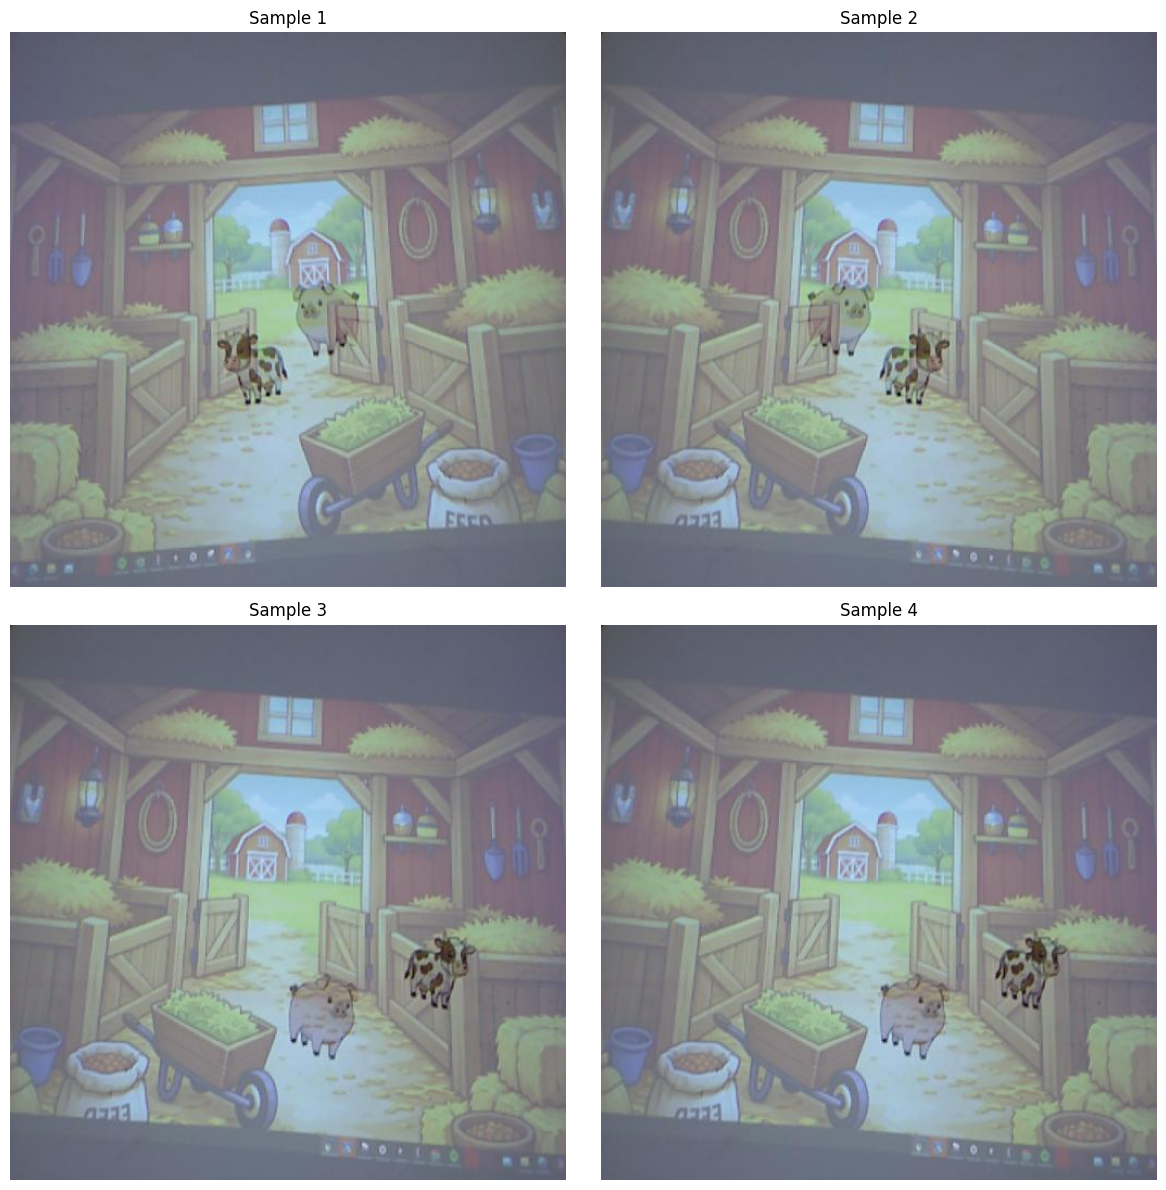

In [4]:
# Visualize some training images
def visualize_samples(data_dir, split='train', num_samples=4):
    """Visualize sample images from the dataset"""
    split_dir = data_dir / split / "images"
    image_files = list(split_dir.glob('*.jpg'))[:num_samples]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(image_files):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Load corresponding label
        label_path = data_dir / split / "labels" / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path, 'r') as f:
                labels = f.readlines()
            
            h, w = img.shape[:2]
            for label in labels:
                parts = label.strip().split()
                if len(parts) == 5:
                    class_id, x_center, y_center, width, height = map(float, parts)
                    x_center, y_center, width, height = x_center * w, y_center * h, width * w, height * h
                    x1, y1 = int(x_center - width/2), int(y_center - height/2)
                    x2, y2 = int(x_center + width/2), int(y_center + height/2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, data_config['names'][int(class_id)], (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f"Sample {idx+1}")
    
    plt.tight_layout()
    plt.show()

# Visualize training samples
visualize_samples(DATA_DIR, split='train', num_samples=4)


## 2. Model Training with Data Augmentation


In [6]:
# Check package versions (for troubleshooting)
print("Package Versions:")
print(f"  PyTorch: {torch.__version__}")
print(f"  Ultralytics: {__import__('ultralytics').__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA version: {torch.version.cuda}")
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

print("\nIf you encounter compatibility errors, try updating packages:")
print("  pip install --upgrade torch torchvision ultralytics")


Package Versions:
  PyTorch: 2.10.0+cpu
  Ultralytics: 8.4.6
  CUDA available: False

If you encounter compatibility errors, try updating packages:
  pip install --upgrade torch torchvision ultralytics


### Alternative: If the above cell fails, use this alternative initialization


In [ ]:
# ALTERNATIVE INITIALIZATION (Use this if Cell 7 fails)
# This method initializes from YAML config instead of pretrained weights
# Uncomment and run this cell if you get compatibility errors

# from ultralytics import YOLO
# 
# # Initialize from architecture YAML (no pretrained weights)
# try:
#     model = YOLO('yolo12n.yaml')  # Architecture only
#     print("✓ Model initialized from YAML architecture!")
#     print("Note: Training will start from scratch (no pretrained weights)")
# except:
#     # Fallback to YOLO8 if YOLO12 not available
#     try:
#         model = YOLO('yolo8n.yaml')
#         print("✓ Model initialized with YOLO8 architecture!")
#     except Exception as e:
#         print(f"Error: {e}")
#         raise


In [11]:
# Initialize YOLO12 model
# YOLO12 is available in ultralytics as 'yolo12n', 'yolo12s', 'yolo12m', 'yolo12l', 'yolo12x'
# We'll use yolo12n (nano) for faster training, but you can change to yolo12s, yolo12m, etc.

# Try different model versions in case of compatibility issues
model_initialized = False
model_attempts = ['yolo12n.pt', 'yolo11n.pt', 'yolo8n.pt']

print("Attempting to load pretrained weights...")
for model_name in model_attempts:
    try:
        print(f"  Trying {model_name}...")
        model = YOLO(model_name)  # Start from pretrained weights
        print(f"✓ Model initialized successfully with {model_name}!")
        print(f"  Model type: {model.model_name}")
        model_initialized = True
        break
    except AttributeError as e:
        if '_utils' in str(e):
            print(f"  ✗ Compatibility issue (PyTorch version mismatch)")
            continue
        else:
            raise
    except (FileNotFoundError, OSError) as e:
        print(f"  ✗ File not found")
        continue
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:50]}...")
        continue

# If pretrained weights fail, try YAML initialization (architecture only)
if not model_initialized:
    print("\n" + "="*60)
    print("Pretrained weights failed. Using YAML architecture instead...")
    print("="*60)
    print("\nNote: Training will start from scratch (no pretrained weights).")
    print("This may take longer but will still work.\n")
    
    yaml_attempts = ['yolo12n.yaml', 'yolo11n.yaml', 'yolo8n.yaml']
    
    for yaml_name in yaml_attempts:
        try:
            print(f"Attempting to load {yaml_name}...")
            model = YOLO(yaml_name)  # Architecture only, no pretrained weights
            print(f"✓ Model initialized successfully with {yaml_name}!")
            print(f"  Model type: {model.model_name}")
            print("  ⚠ Training will start from scratch (no pretrained weights)")
            model_initialized = True
            break
        except Exception as e:
            print(f"  ✗ Error: {str(e)[:80]}")
            continue
    
    if not model_initialized:
        print("\n" + "="*60)
        print("ERROR: Could not initialize any model.")
        print("="*60)
        print("\nSOLUTION: Please update your packages:")
        print("  pip install --upgrade torch torchvision ultralytics")
        print("\nOr install a compatible PyTorch version:")
        print("  pip install torch==2.1.0 torchvision==0.16.0")
        print("="*60)
        raise RuntimeError("Model initialization failed. Please update packages.")

print("\n" + "="*60)
print("Model ready for training!")
print("="*60)


Attempting to load pretrained weights...
  Trying yolo12n.pt...
  ✗ Compatibility issue (PyTorch version mismatch)
  Trying yolo11n.pt...
  ✗ Compatibility issue (PyTorch version mismatch)
  Trying yolo8n.pt...
  ✗ File not found

Pretrained weights failed. Using YAML architecture instead...

Note: Training will start from scratch (no pretrained weights).
This may take longer but will still work.

Attempting to load yolo12n.yaml...
✓ Model initialized successfully with yolo12n.yaml!
  Model type: yolo12n.yaml
  ⚠ Training will start from scratch (no pretrained weights)

Model ready for training!


In [ ]:
# Training configuration with data augmentation
# Ultralytics has built-in augmentation, but we can customize it

# Check PyTorch version for compatibility
torch_version = torch.__version__
print(f"PyTorch version: {torch_version}")
print("Note: Using SGD optimizer for better compatibility with older PyTorch versions")

# Use SGD instead of AdamW for better compatibility with older PyTorch
# If you update PyTorch, you can change this back to 'AdamW'
optimizer_choice = 'SGD'  # More compatible with older PyTorch
# optimizer_choice = 'AdamW'  # Uncomment if you upgrade PyTorch

training_config = {
    'data': str(DATA_YAML),  # Path to data.yaml
    'epochs': 100,  # Number of training epochs
    'imgsz': 640,  # Image size
    'batch': 16,  # Batch size (adjust based on GPU memory)
    'device': device,
    'workers': 4,  # Number of worker threads
    'project': str(BASE_DIR / 'yolo_training' / 'runs'),
    'name': 'yolo12_animal_detection',
    'exist_ok': True,  # Overwrite existing project/name
    'pretrained': False,  # Set to False since we're using YAML architecture
    'optimizer': optimizer_choice,  # Optimizer: SGD, Adam, AdamW, NAdam, RAdam, RMSProp
    'verbose': True,
    'seed': 42,
    'deterministic': True,
    'single_cls': False,
    'rect': False,  # Rectangular training
    'cos_lr': False,  # Cosine LR scheduler
    'close_mosaic': 10,  # Disable mosaic augmentation for last N epochs
    'resume': False,  # Resume from last checkpoint
    'amp': False,  # Automatic Mixed Precision (AMP) - Disabled for older PyTorch compatibility
    'fraction': 1.0,  # Dataset fraction to use
    'profile': False,  # Profile ONNX and TensorRT speeds during training
    'freeze': None,  # Freeze layers: backbone=10, first3=0 1 2
    'lr0': 0.01,  # Initial learning rate
    'lrf': 0.01,  # Final learning rate (lr0 * lrf)
    'momentum': 0.937,  # SGD momentum/Adam beta1
    'weight_decay': 0.0005,  # Optimizer weight decay
    'warmup_epochs': 3.0,  # Warmup epochs
    'warmup_momentum': 0.8,  # Warmup initial momentum
    'warmup_bias_lr': 0.1,  # Warmup initial bias lr
    'box': 7.5,  # Box loss gain
    'cls': 0.5,  # Class loss gain
    'dfl': 1.5,  # DFL loss gain
    'pose': 12.0,  # Pose loss gain
    'kobj': 1.0,  # Keypoint obj loss gain
    'label_smoothing': 0.0,  # Label smoothing (fraction)
    'nbs': 64,  # Nominal batch size
    'hsv_h': 0.015,  # Image HSV-Hue augmentation (fraction)
    'hsv_s': 0.7,  # Image HSV-Saturation augmentation (fraction)
    'hsv_v': 0.4,  # Image HSV-Value augmentation (fraction)
    'degrees': 0.0,  # Image rotation (+/- deg)
    'translate': 0.1,  # Image translation (+/- fraction)
    'scale': 0.5,  # Image scale (+/- gain)
    'shear': 0.0,  # Image shear (+/- deg)
    'perspective': 0.0,  # Image perspective (+/- fraction), range 0-0.001
    'flipud': 0.0,  # Image flip up-down (probability)
    'fliplr': 0.5,  # Image flip left-right (probability)
    'mosaic': 1.0,  # Image mosaic (probability)
    'mixup': 0.0,  # Image mixup (probability)
    'copy_paste': 0.0,  # Segment copy-paste (probability)
}

print("Training configuration:")
for key, value in training_config.items():
    print(f"  {key}: {value}")


Training configuration:
  data: c:\Users\CHARBEL\Desktop\Lingo\animales\data.yaml
  epochs: 100
  imgsz: 640
  batch: 16
  device: cpu
  workers: 4
  project: c:\Users\CHARBEL\Desktop\Lingo\yolo_training\runs
  name: yolo12_animal_detection
  exist_ok: True
  pretrained: True
  optimizer: AdamW
  verbose: True
  seed: 42
  deterministic: True
  single_cls: False
  rect: False
  cos_lr: False
  close_mosaic: 10
  resume: False
  amp: True
  fraction: 1.0
  profile: False
  freeze: None
  lr0: 0.01
  lrf: 0.01
  momentum: 0.937
  weight_decay: 0.0005
  warmup_epochs: 3.0
  warmup_momentum: 0.8
  warmup_bias_lr: 0.1
  box: 7.5
  cls: 0.5
  dfl: 1.5
  pose: 12.0
  kobj: 1.0
  label_smoothing: 0.0
  nbs: 64
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 0.0
  translate: 0.1
  scale: 0.5
  shear: 0.0
  perspective: 0.0
  flipud: 0.0
  fliplr: 0.5
  mosaic: 1.0
  mixup: 0.0
  copy_paste: 0.0


### ⚠️ IMPORTANT: PyTorch Compatibility Check

If you get `AttributeError: module 'torch' has no attribute '_utils'` during training, you need to upgrade PyTorch.

**Quick Fix:**
```bash
pip install --upgrade torch torchvision torchaudio
```

Or install a specific compatible version:
```bash
pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0
```

After upgrading, **restart your Jupyter kernel** and run the cells again.


In [ ]:
# Check if PyTorch version is compatible
import torch
torch_version = torch.__version__
print(f"Current PyTorch version: {torch_version}")

# Check for _utils attribute (required for newer Ultralytics)
has_utils = hasattr(torch, '_utils')
print(f"Has torch._utils: {has_utils}")

if not has_utils:
    print("\n" + "="*60)
    print("⚠️  WARNING: PyTorch version is incompatible!")
    print("="*60)
    print("\nYour PyTorch version is too old for Ultralytics 8.4.6")
    print("You need to upgrade PyTorch to continue training.")
    print("\nRun this command in your terminal:")
    print("  pip install --upgrade torch torchvision torchaudio")
    print("\nOr install a specific version:")
    print("  pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0")
    print("\nAfter upgrading, restart your Jupyter kernel!")
    print("="*60)
    print("\n⚠️  Training may fail with the current PyTorch version.")
    print("Proceeding anyway, but errors are likely...")
else:
    print("✓ PyTorch version appears compatible")


In [13]:
# Start training
print("Starting training...")
print("=" * 50)

results = model.train(**training_config)

print("=" * 50)
print("Training completed!")


Starting training...
New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.6  Python-3.10.11 torch-2.10.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\CHARBEL\Desktop\Lingo\animales\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_d

AttributeError: module 'torch' has no attribute '_utils'

## 3. Model Evaluation


In [ ]:
# Load the best model from training
best_model_path = BASE_DIR / 'yolo_training' / 'runs' / 'yolo12_animal_detection' / 'weights' / 'best.pt'
print(f"Loading best model from: {best_model_path}")

if best_model_path.exists():
    best_model = YOLO(str(best_model_path))
    print("Best model loaded successfully!")
else:
    print("Best model not found, using last checkpoint...")
    last_model_path = BASE_DIR / 'yolo_training' / 'runs' / 'yolo12_animal_detection' / 'weights' / 'last.pt'
    if last_model_path.exists():
        best_model = YOLO(str(last_model_path))
        print("Last model loaded successfully!")
    else:
        print("No model found, using original model")
        best_model = model


In [ ]:
# Evaluate on validation set
print("Evaluating on validation set...")
val_metrics = best_model.val(data=str(DATA_YAML), imgsz=640, batch=16, device=device)

print("\nValidation Metrics:")
print(f"mAP50: {val_metrics.box.map50:.4f}")
print(f"mAP50-95: {val_metrics.box.map:.4f}")
print(f"Precision: {val_metrics.box.mp:.4f}")
print(f"Recall: {val_metrics.box.mr:.4f}")

# Print per-class metrics
print("\nPer-class mAP50:")
for i, class_name in enumerate(data_config['names']):
    if i < len(val_metrics.box.maps50):
        print(f"  {class_name}: {val_metrics.box.maps50[i]:.4f}")


In [ ]:
# Evaluate on test set
print("Evaluating on test set...")
test_metrics = best_model.val(data=str(DATA_YAML), split='test', imgsz=640, batch=16, device=device)

print("\nTest Metrics:")
print(f"mAP50: {test_metrics.box.map50:.4f}")
print(f"mAP50-95: {test_metrics.box.map:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f}")
print(f"Recall: {test_metrics.box.mr:.4f}")


In [ ]:
# Visualize predictions on test images
def visualize_predictions(model, data_dir, split='test', num_samples=6):
    """Visualize model predictions on test images"""
    split_dir = data_dir / split / "images"
    image_files = list(split_dir.glob('*.jpg'))[:num_samples]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(image_files):
        # Run inference
        results = model(str(img_path), conf=0.25, imgsz=640)
        
        # Plot
        annotated_img = results[0].plot()
        axes[idx].imshow(annotated_img)
        axes[idx].axis('off')
        axes[idx].set_title(f"Test Image {idx+1}")
    
    plt.tight_layout()
    plt.show()

# Visualize test predictions
visualize_predictions(best_model, DATA_DIR, split='test', num_samples=6)


## 4. Model Export


In [ ]:
# Export model to different formats
export_dir = BASE_DIR / 'yolo_training' / 'exports'
export_dir.mkdir(exist_ok=True)

print("Exporting model to different formats...")

# Export to ONNX (for cross-platform inference)
print("\n1. Exporting to ONNX...")
onnx_path = best_model.export(format='onnx', imgsz=640, optimize=True)
print(f"ONNX model saved to: {onnx_path}")

# Export to TorchScript
print("\n2. Exporting to TorchScript...")
torchscript_path = best_model.export(format='torchscript', imgsz=640)
print(f"TorchScript model saved to: {torchscript_path}")

# Copy best.pt to exports folder for easy access
import shutil
exported_model_path = export_dir / 'best.pt'
shutil.copy(best_model_path, exported_model_path)
print(f"\nBest model (.pt) copied to: {exported_model_path}")

print("\nModel export completed!")
print(f"All exported models are in: {export_dir}")


## 5. Training Summary

The model has been trained and exported. You can now use it for inference with the Kinect camera.
